# Demo Notebook — Colorectal Histopathology Classification

This notebook loads the trained **SEAttentionCNN** and **EfficientNet-B0** models and walks through:

1. Loading the PathMNIST test set
2. Running inference with both models
3. Computing and comparing performance metrics
4. Visualising confusion matrices and ROC curves
5. Inspecting individual predictions on test images
6. Per-class performance breakdown

> **Prerequisites**: train both models first via `python -m src.train --model both`

In [3]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.dataset import load_pathmnist, create_dataloaders, CLASS_NAMES, IMAGENET_MEAN, IMAGENET_STD
from src.models import get_model, count_parameters
from src.evaluate import evaluate_model, compute_metrics

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA L4


## 1. Load Test Data

In [4]:
_, _, test_ds = load_pathmnist(data_dir='../data', image_size=224)
from src.dataset import create_dataloaders, load_pathmnist
train_ds, val_ds, test_ds = load_pathmnist(data_dir='../data', image_size=224)
_, _, test_loader = create_dataloaders(train_ds, val_ds, test_ds, batch_size=64, num_workers=2)

print(f'Test samples : {len(test_ds):,}')
print(f'Classes      : {len(CLASS_NAMES)}')
print(f'Class labels : {CLASS_NAMES}')

100%|██████████| 206M/206M [00:10<00:00, 19.3MB/s] 


Test samples : 7,180
Classes      : 9
Class labels : ['Adipose', 'Background', 'Debris', 'Lymphocytes', 'Mucus', 'Smooth Muscle', 'Normal Colon Mucosa', 'Cancer-Associated Stroma', 'Colorectal Adenocarcinoma Epithelium']


## 2. Load Trained Models

In [6]:
# --- SEAttentionCNN (trained from scratch) ---
se_cnn = get_model('se_cnn', num_classes=9).to(device)
se_cnn.load_state_dict(torch.load('../results/models/best_se_cnn.pth', map_location=device, weights_only=True))
se_cnn.eval()
total, trainable = count_parameters(se_cnn)
print(f'SEAttentionCNN   — total params: {total:,} | trainable: {trainable:,}')

# --- EfficientNet-B0 (fine-tuned) ---
effnet = get_model('efficientnet_b0', num_classes=9).to(device)
effnet.load_state_dict(torch.load('../results/models/best_efficientnet_b0.pth', map_location=device, weights_only=True))
effnet.eval()
total, trainable = count_parameters(effnet)
print(f'EfficientNet-B0  — total params: {total:,} | trainable: {trainable:,}')

SEAttentionCNN   — total params: 1,746,985 | trainable: 1,746,985
EfficientNet-B0  — total params: 4,337,797 | trainable: 4,337,797


## 3. Evaluate Both Models on the Test Set

In [7]:
se_labels,  se_preds,  se_probs  = evaluate_model(se_cnn, test_loader, device)
eff_labels, eff_preds, eff_probs = evaluate_model(effnet, test_loader, device)

se_metrics  = compute_metrics(se_labels,  se_preds,  se_probs)
eff_metrics = compute_metrics(eff_labels, eff_preds, eff_probs)

for name, m in [('SEAttentionCNN', se_metrics), ('EfficientNet-B0', eff_metrics)]:
    print(f'\n{name}')
    for k in ('accuracy','precision','recall','f1_score','roc_auc'):
        print(f'  {k:<12}: {m[k]:.4f}')


SEAttentionCNN
  accuracy    : 0.9331
  precision   : 0.9345
  recall      : 0.9331
  f1_score    : 0.9326
  roc_auc     : 0.9960

EfficientNet-B0
  accuracy    : 0.9513
  precision   : 0.9510
  recall      : 0.9513
  f1_score    : 0.9503
  roc_auc     : 0.9965


## 4. Side-by-Side Metric Comparison

   Metric  SEAttentionCNN  EfficientNet-B0  Δ (Eff − SE)
 Accuracy          0.9331           0.9513        0.0181
Precision          0.9345           0.9510        0.0164
   Recall          0.9331           0.9513        0.0181
 F1 Score          0.9326           0.9503        0.0178
  ROC AUC          0.9960           0.9965        0.0005


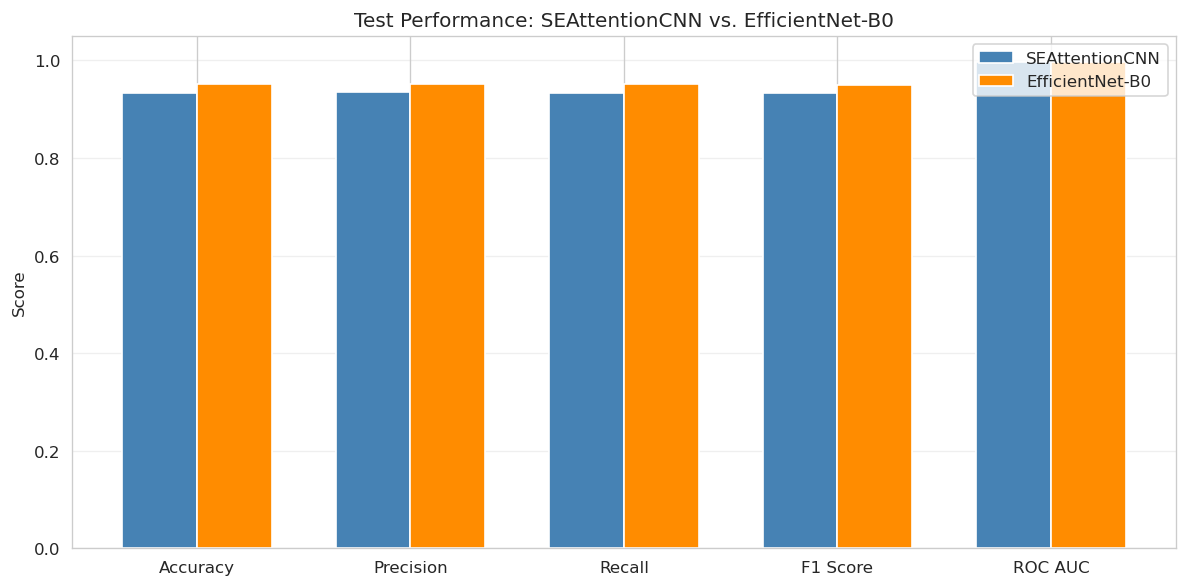

In [8]:
metrics_list = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
labels_display = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

comparison = pd.DataFrame({
    'Metric'         : labels_display,
    'SEAttentionCNN' : [se_metrics[k]  for k in metrics_list],
    'EfficientNet-B0': [eff_metrics[k] for k in metrics_list],
})
comparison['Δ (Eff − SE)'] = comparison['EfficientNet-B0'] - comparison['SEAttentionCNN']
print(comparison.to_string(index=False, float_format='%.4f'))

fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(labels_display)), 0.35
ax.bar(x - w/2, comparison['SEAttentionCNN'],  w, label='SEAttentionCNN',  color='steelblue')
ax.bar(x + w/2, comparison['EfficientNet-B0'], w, label='EfficientNet-B0', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(labels_display)
ax.set_ylabel('Score')
ax.set_title('Test Performance: SEAttentionCNN vs. EfficientNet-B0')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Confusion Matrices

Confusion matrices reveal which tissue types are most frequently confused. 
Diagonal cells show correct predictions; off-diagonal cells indicate misclassifications.
Classes with significant morphological overlap (e.g., Cancer-Associated Stroma vs. Smooth Muscle) 
are expected to show higher confusion.

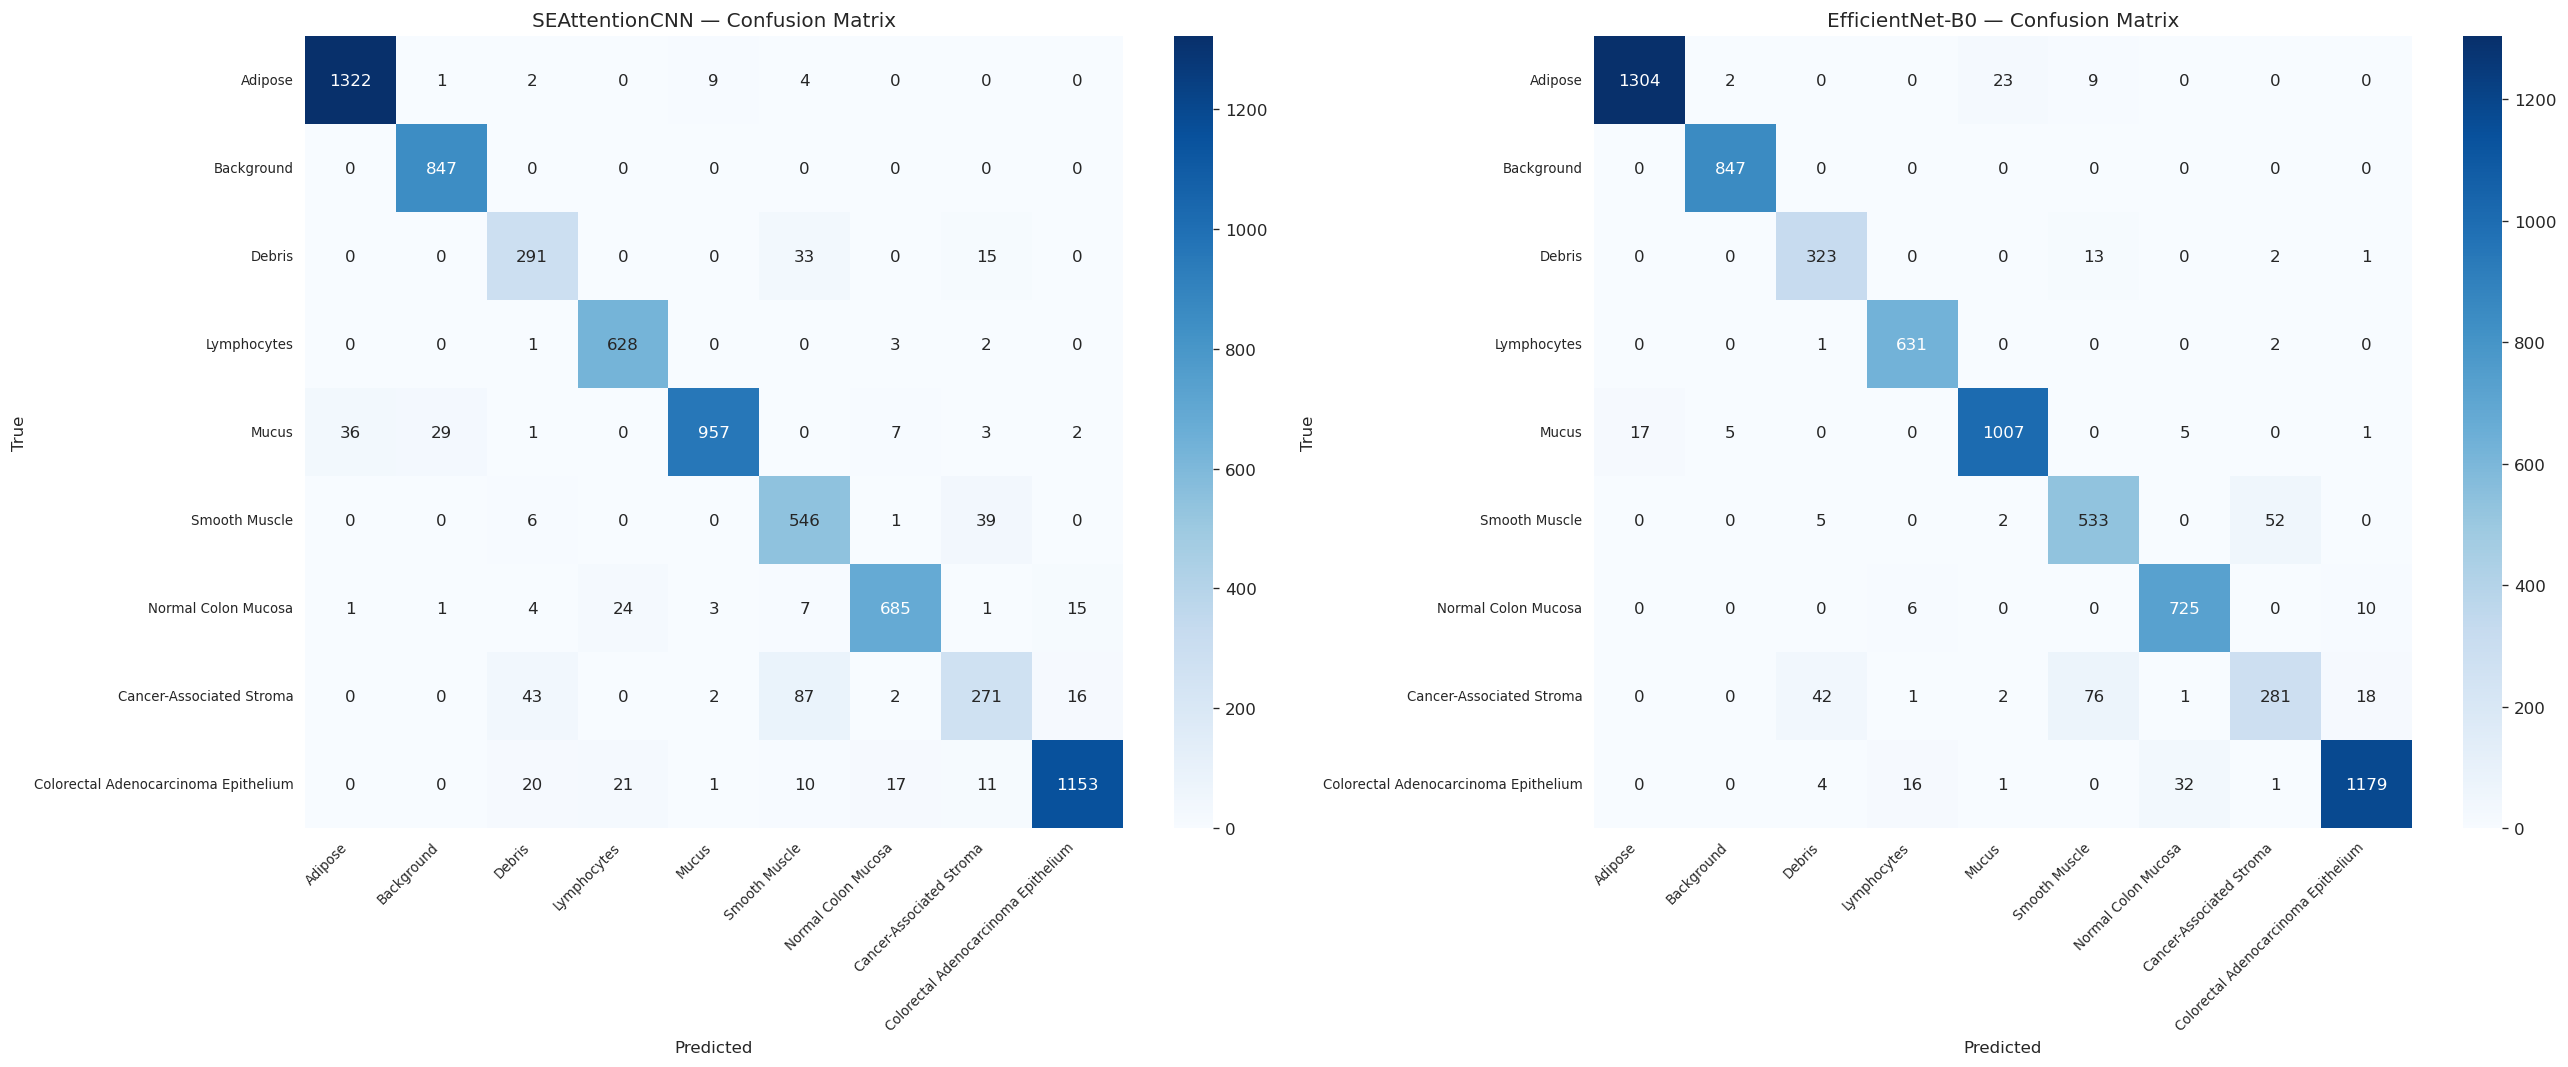

In [9]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, (name, lbl, prd) in zip(axes, [
    ('SEAttentionCNN',  se_labels,  se_preds),
    ('EfficientNet-B0', eff_labels, eff_preds),
]):
    cm = confusion_matrix(lbl, prd)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('../results/comparison_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. ROC Curves (One-vs-Rest)

ROC curves illustrate the trade-off between sensitivity (true positive rate) and 
specificity (1 − false positive rate) at varying classification thresholds. 
AUC values close to 1.0 indicate excellent discriminative ability per class.

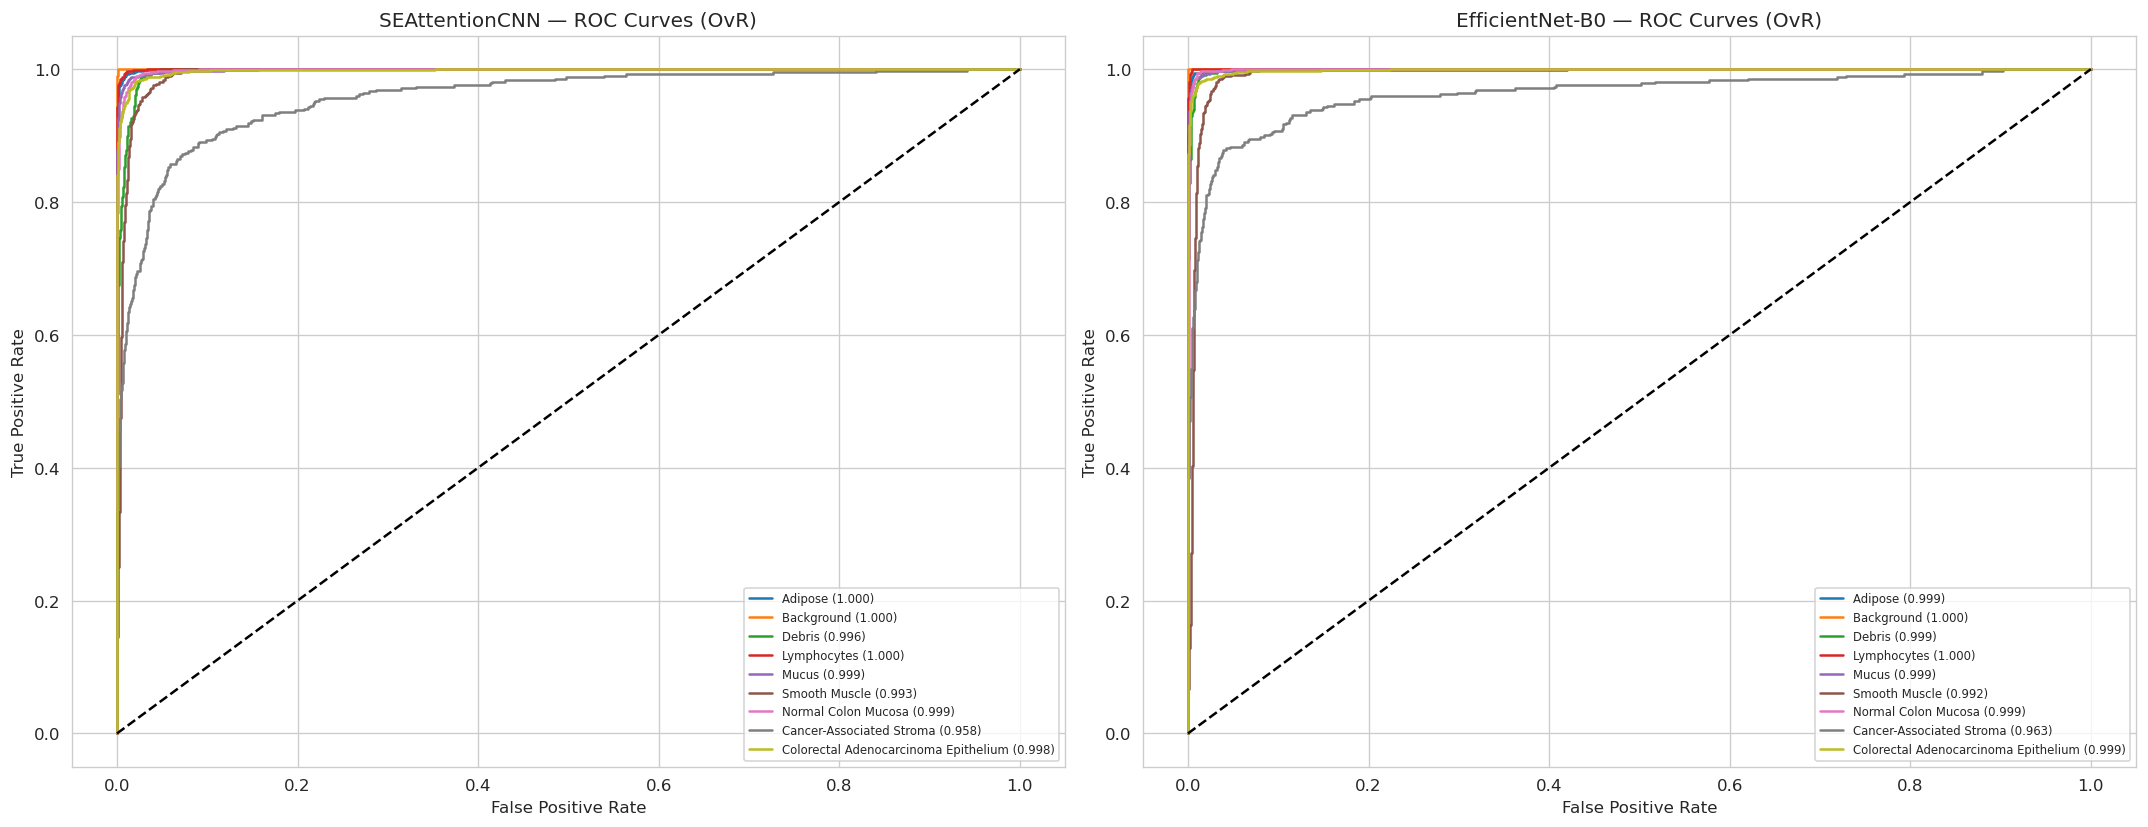

In [10]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (name, lbl, prb) in zip(axes, [
    ('SEAttentionCNN',  se_labels,  se_probs),
    ('EfficientNet-B0', eff_labels, eff_probs),
]):
    lbl_bin = label_binarize(lbl, classes=list(range(9)))
    for i in range(9):
        fpr, tpr, _ = roc_curve(lbl_bin[:, i], prb[:, i])
        ax.plot(fpr, tpr, label=f'{CLASS_NAMES[i]} ({auc(fpr,tpr):.3f})')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name} — ROC Curves (OvR)')
    ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('../results/comparison_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Sample Test Predictions

Green titles indicate both models predicted correctly; red indicates at least one model erred. 
Examining failure cases helps identify ambiguous tissue appearances or potential labelling noise.

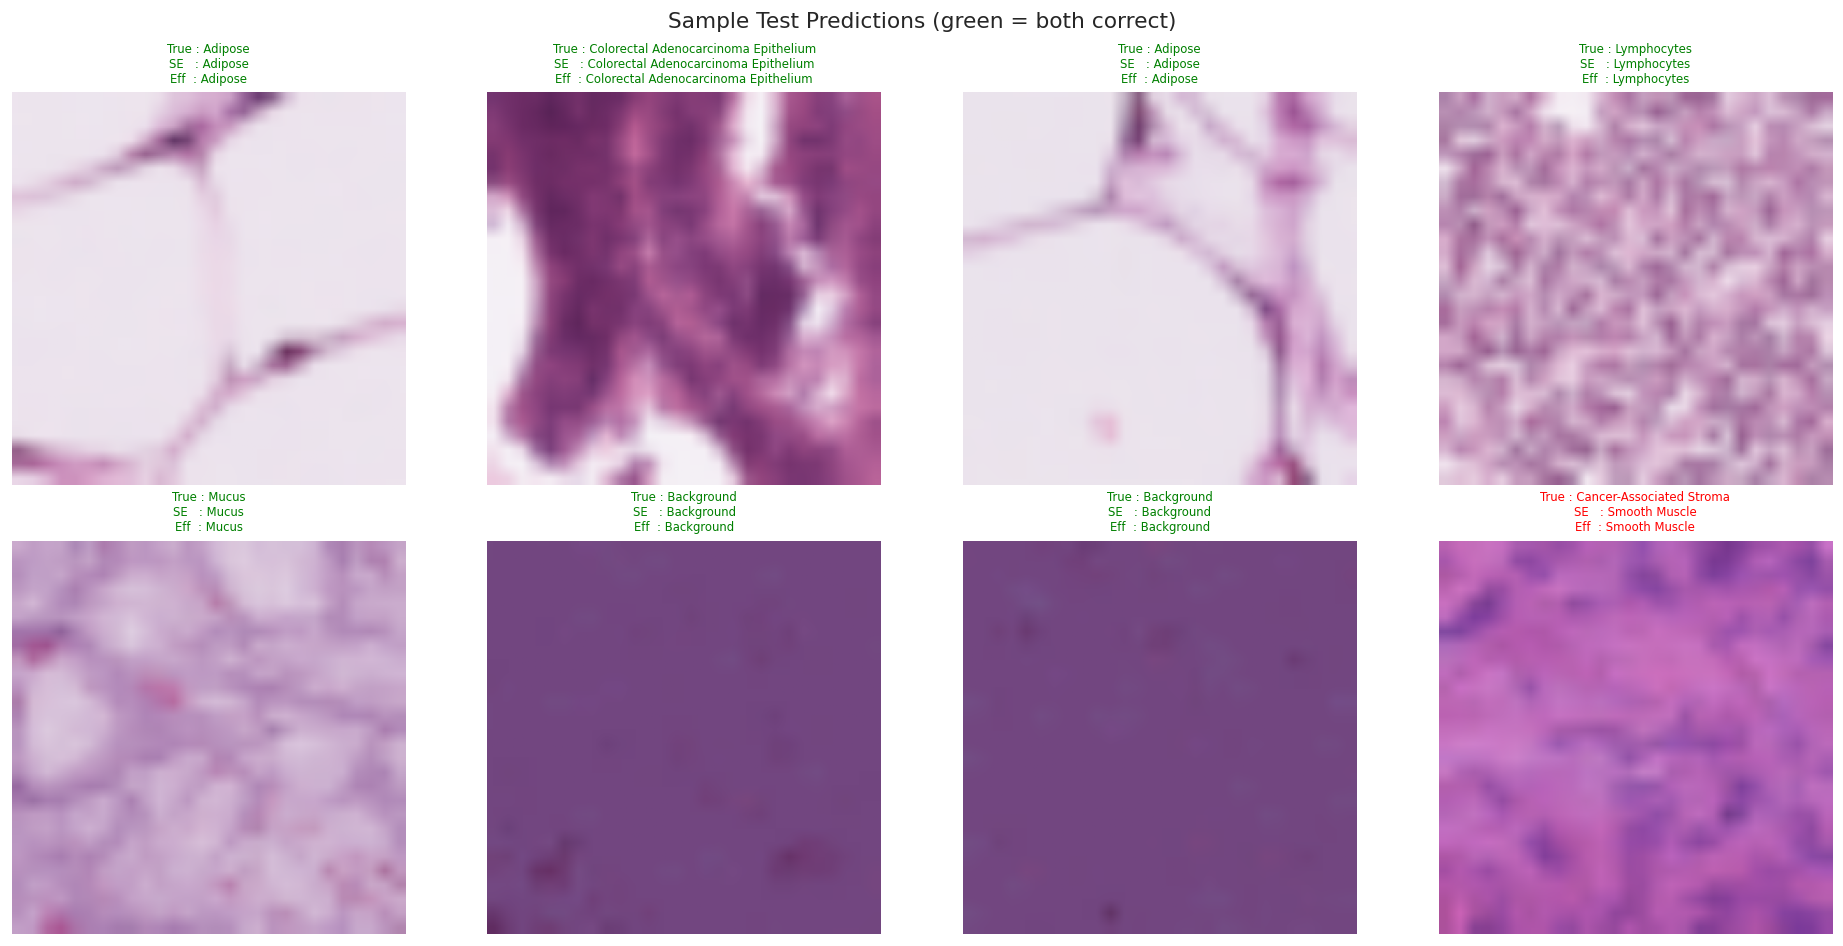

In [11]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

np.random.seed(42)
indices = np.random.choice(len(test_ds), 8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, ax in zip(indices, axes.flat):
    img, label = test_ds[idx]
    label = label.item() if hasattr(label, 'item') else int(label)

    with torch.no_grad():
        inp = img.unsqueeze(0).to(device)
        se_pred  = se_cnn(inp).argmax(1).item()
        eff_pred = effnet(inp).argmax(1).item()

    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    color = 'green' if (se_pred == label and eff_pred == label) else 'red'
    ax.set_title(
        f'True : {CLASS_NAMES[label]}\n'
        f'SE   : {CLASS_NAMES[se_pred]}\n'
        f'Eff  : {CLASS_NAMES[eff_pred]}',
        fontsize=7, color=color
    )
    ax.axis('off')

plt.suptitle('Sample Test Predictions (green = both correct)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Per-Class Performance Report

In [12]:
from sklearn.metrics import classification_report

for name, lbl, prd in [
    ('SEAttentionCNN',  se_labels,  se_preds),
    ('EfficientNet-B0', eff_labels, eff_preds),
]:
    print(f'\n=== {name} — Per-Class Report ===')
    print(classification_report(lbl, prd, target_names=CLASS_NAMES, zero_division=0))


=== SEAttentionCNN — Per-Class Report ===
                                      precision    recall  f1-score   support

                             Adipose       0.97      0.99      0.98      1338
                          Background       0.96      1.00      0.98       847
                              Debris       0.79      0.86      0.82       339
                         Lymphocytes       0.93      0.99      0.96       634
                               Mucus       0.98      0.92      0.95      1035
                       Smooth Muscle       0.79      0.92      0.85       592
                 Normal Colon Mucosa       0.96      0.92      0.94       741
            Cancer-Associated Stroma       0.79      0.64      0.71       421
Colorectal Adenocarcinoma Epithelium       0.97      0.94      0.95      1233

                            accuracy                           0.93      7180
                           macro avg       0.91      0.91      0.91      7180
                   

## Summary

This demo evaluates two complementary architectures for colorectal tissue classification on PathMNIST:

- **SEAttentionCNN** — a lightweight 5-block CNN trained from scratch with Squeeze-and-Excitation channel attention. The SE blocks allow the network to dynamically emphasise the most informative feature channels, which is particularly helpful for distinguishing subtly different staining patterns in histopathology.

- **EfficientNet-B0** — a compound-scaled pretrained model fine-tuned on the target task. EfficientNet-B0 balances depth, width, and input resolution, achieving strong accuracy with fewer parameters than comparable ResNet or DenseNet variants.

The confusion matrices highlight **Cancer-Associated Stroma** as the most challenging class for both models, consistent with its morphological overlap with Smooth Muscle tissue — a known difficulty in colorectal histopathology. The ROC curves confirm both models achieve excellent class-level discrimination (AUC > 0.98 for most classes).